In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
x,y_true=make_blobs(n_samples=500,centers=3,cluster_std=0.60,random_state=42)


In [3]:
x

array([[-6.1900632 , -7.30201545],
       [ 3.02174685,  1.94059276],
       [ 5.9537606 ,  1.48819071],
       [-2.74446251,  8.13617716],
       [ 5.36060719,  1.72832446],
       [ 5.13808033,  1.45951939],
       [-5.34357647, -6.93774553],
       [ 4.80215293,  1.94302682],
       [ 3.99930658,  1.88774199],
       [-7.25451834, -6.86445496],
       [ 4.25193511,  1.32424088],
       [-1.81404028,  8.52187674],
       [-1.2293776 ,  7.84303345],
       [-2.16666332,  9.69562551],
       [ 4.81374375,  3.21841016],
       [ 5.27493353,  0.91792599],
       [-2.5524037 ,  9.61640587],
       [-7.5532604 , -6.65066375],
       [-6.8302568 , -6.24082137],
       [-3.17299861,  8.29656215],
       [ 3.80073829,  2.31095123],
       [-2.38387947,  7.83848405],
       [ 4.98581301,  2.15991978],
       [-5.94031277, -6.91955975],
       [-7.14748736, -6.7636556 ],
       [ 4.87655012,  1.720579  ],
       [ 4.48689251,  2.87556548],
       [-6.4081471 , -6.62483506],
       [-6.71939703,

In [4]:
df=pd.DataFrame(x,columns=['feature1','feature2'])

In [5]:
df

,feature1,feature2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [6]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(df)

In [7]:
inertia=[]
k_range=range(1,10)
for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

In [8]:
inertia

[1000.0000000000006,
 297.8954141051723,
 11.575484723104985,
 9.752067977356848,
 8.257175272446279,
 6.917577320416797,
 6.334755391595288,
 5.704177177901426,
 5.060234133532074]

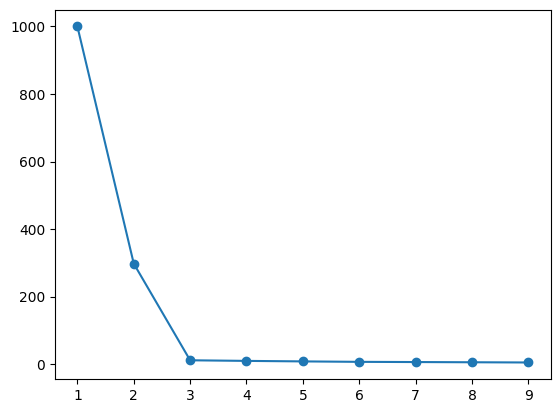

In [9]:
plt.plot(k_range,inertia,marker='o')

In [10]:
kmeans_final=KMeans(n_clusters=7,random_state=42)
cluster_labels=kmeans_final.fit_predict(x_scaled)

In [11]:
cluster_labels

array([5, 3, 0, 4, 0, 0, 1, 0, 3, 6, 3, 2, 2, 2, 0, 0, 4, 6, 6, 4, 3, 2,
       0, 1, 6, 0, 0, 1, 1, 2, 0, 2, 4, 4, 0, 3, 3, 3, 6, 1, 3, 2, 4, 2,
       2, 0, 3, 0, 3, 6, 6, 4, 6, 5, 0, 4, 2, 6, 0, 6, 6, 2, 3, 5, 3, 6,
       0, 5, 2, 0, 0, 0, 0, 5, 4, 6, 2, 3, 2, 4, 5, 2, 3, 2, 6, 6, 6, 1,
       3, 2, 5, 0, 4, 0, 0, 5, 2, 4, 2, 5, 3, 2, 2, 6, 5, 2, 4, 5, 4, 6,
       6, 6, 1, 5, 1, 3, 4, 1, 3, 5, 2, 2, 3, 3, 1, 0, 4, 3, 6, 5, 1, 0,
       3, 1, 0, 6, 1, 6, 3, 4, 5, 5, 0, 3, 5, 6, 6, 4, 2, 4, 3, 6, 3, 3,
       2, 6, 2, 5, 0, 3, 1, 6, 2, 2, 1, 4, 4, 0, 6, 6, 1, 2, 2, 1, 5, 4,
       4, 3, 0, 0, 2, 1, 2, 2, 1, 6, 2, 0, 2, 5, 6, 1, 5, 5, 4, 0, 2, 2,
       6, 0, 2, 2, 1, 6, 3, 5, 3, 4, 2, 6, 1, 0, 5, 4, 2, 5, 2, 5, 2, 0,
       3, 4, 6, 4, 3, 2, 4, 5, 3, 3, 3, 3, 4, 6, 5, 6, 2, 0, 2, 0, 3, 3,
       4, 4, 1, 5, 0, 4, 2, 3, 2, 2, 4, 2, 3, 4, 6, 4, 1, 4, 2, 2, 6, 4,
       3, 0, 0, 4, 0, 3, 2, 4, 0, 1, 4, 4, 4, 2, 6, 6, 2, 3, 2, 4, 5, 2,
       0, 1, 3, 0, 1, 4, 4, 2, 6, 4, 5, 3, 0, 2, 0,

<Axes: xlabel='feature1', ylabel='feature2'>

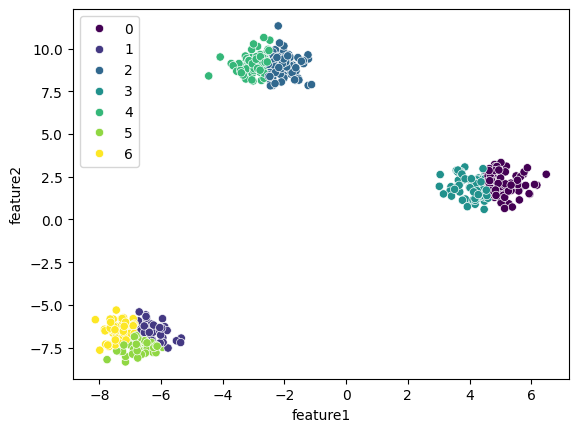

In [12]:
sns.scatterplot(x='feature1',y='feature2',hue=cluster_labels,data=df,palette='viridis')

In [13]:
#difference between K_means and DBScan
from sklearn.datasets import make_moons

In [14]:
x,y_true=make_moons(n_samples=500,noise=0.05,random_state=42)

In [15]:
from sklearn.cluster import KMeans,DBSCAN

In [16]:
df=pd.DataFrame(x,columns=['feature1','feature2'])

In [17]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(df)

In [18]:
kmaens=KMeans(n_clusters=2,random_state=42)
k_cluster_labels=kmaens.fit_predict(x_scaled)

In [19]:
df['kmeans_cluster']=k_cluster_labels

<Axes: xlabel='feature1', ylabel='feature2'>

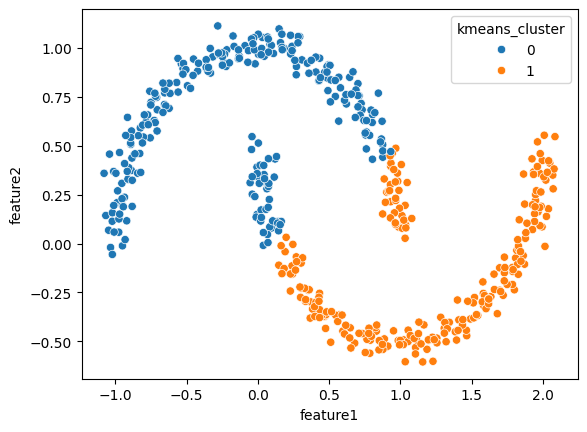

In [20]:
sns.scatterplot(x='feature1',y='feature2',hue='kmeans_cluster',data=df,palette='tab10')


In [21]:
#DB
dbscan=DBSCAN(eps=0.3,min_samples=5)
d_cluster_labels=dbscan.fit_predict(x_scaled)

In [22]:
df['dbscan_cluster']=d_cluster_labels

<Axes: xlabel='feature1', ylabel='feature2'>

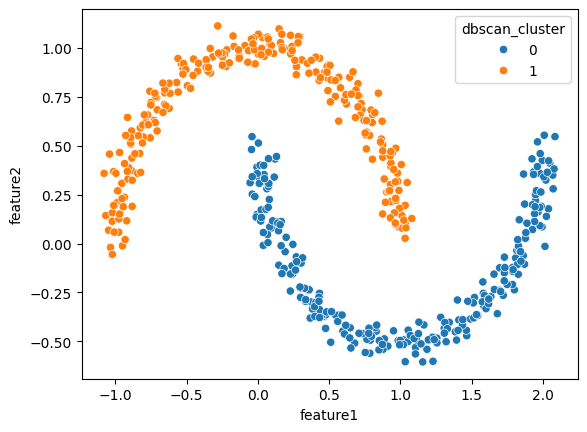

In [23]:
sns.scatterplot(x='feature1',y='feature2',hue='dbscan_cluster',data=df,palette='tab10')
